In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from src.loading import load_imerg_feature_stats, load_dyamond

# IMERG vs DYAMOND: Feature Size Distributions

Compare the size distribution (`area_km2`) of precipitation features between the
IMERG observations and the DYAMOND global storm-resolving models, following the
style of the DYAMOND-vs-GPM comparison notebooks.

Two cases are shown side by side:

- **All features** — every feature returned by the loaders.
- **Fits in swath** — only features with `fits_in_swath == True`, i.e. features
  fully contained within a single satellite-swath footprint.

All datasets are on the same `0p1deg` grid, and the loaders apply the project's
standard cuts (`size_px >= 5`, `max_precip_mm_hr >= 10`, `|centroid_lat| <= 20`).
Feature *area* (km²) is used as the size metric so it is comparable across
datasets despite differing native model resolutions.

In [2]:
RESOLUTION = "0p1"
DYAMOND_MODELS = [
    "GEOS-3km",
    "gSAM-4km",
    "ICON-SAP-5km",
    "MPAS-3km",
    "SCREAM-3km",
    "SHiELD-3km",
]

# IMERG first so it acts as the observational reference (like GPM elsewhere).
feature_data = {"IMERG": load_imerg_feature_stats()}
for model in DYAMOND_MODELS:
    feature_data[model] = load_dyamond(model, RESOLUTION)

# IMERG -> black & thick; DYAMOND models -> matplotlib color cycle.
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
model_colors = {}
cycle_index = 0
for name in feature_data:
    if name == "IMERG":
        model_colors[name] = "black"
    else:
        model_colors[name] = color_cycle[cycle_index % len(color_cycle)]
        cycle_index += 1

for name, df in feature_data.items():
    print(f"{name:15s} n={df.height:7d}  fits_in_swath_frac={df['fits_in_swath'].mean():.3f}")

IMERG           n=  31908  fits_in_swath_frac=0.308
GEOS-3km        n= 164663  fits_in_swath_frac=0.960
gSAM-4km        n= 218740  fits_in_swath_frac=0.970
ICON-SAP-5km    n= 309308  fits_in_swath_frac=0.994
MPAS-3km        n= 116097  fits_in_swath_frac=0.945
SCREAM-3km      n= 324077  fits_in_swath_frac=0.991
SHiELD-3km      n= 121435  fits_in_swath_frac=0.935


## Size distribution (CDF)

Cumulative distribution of feature area on a log x-axis, for all features (left)
and for only those features that fit within a single swath (right).

In [3]:
def plot_cdf(series: pl.Series, ax: plt.Axes = None, label: str = None, **kwargs):
    values = series.drop_nulls().sort().to_numpy()
    cdf = np.arange(1, len(values) + 1) / len(values)
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()
    ax.plot(values, cdf, label=label, **kwargs)
    return fig, ax

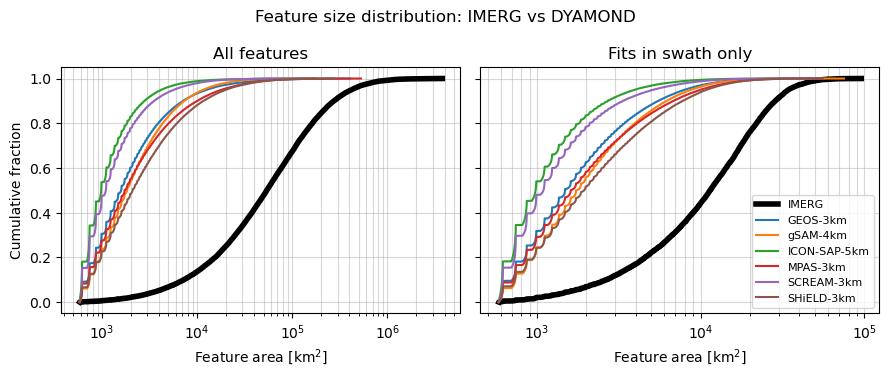

In [4]:
subsets = {
    "All features": lambda df: df,
    "Fits in swath only": lambda df: df.filter(pl.col("fits_in_swath")),
}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)

for ax, (title, subset) in zip(axes, subsets.items()):
    for name, df in feature_data.items():
        kwargs = {"label": name, "color": model_colors[name]}
        if name == "IMERG":
            kwargs["lw"] = 4
        plot_cdf(subset(df)["area_km2"], ax=ax, **kwargs)
    ax.set_xscale("log")
    ax.set_xlabel("Feature area [km$^2$]")
    ax.set_title(title)
    ax.grid(alpha=0.5, which="both")

axes[0].set_ylabel("Cumulative fraction")
axes[1].legend(loc="lower right", fontsize=8)
fig.suptitle("Feature size distribution: IMERG vs DYAMOND")
fig.tight_layout()

## Median feature size

Median feature area for each dataset, comparing all features against the
fits-in-swath subset. Because large features are the ones most likely to cross a
swath boundary, restricting to fits-in-swath removes the biggest features and so
lowers the median — most strongly for IMERG.

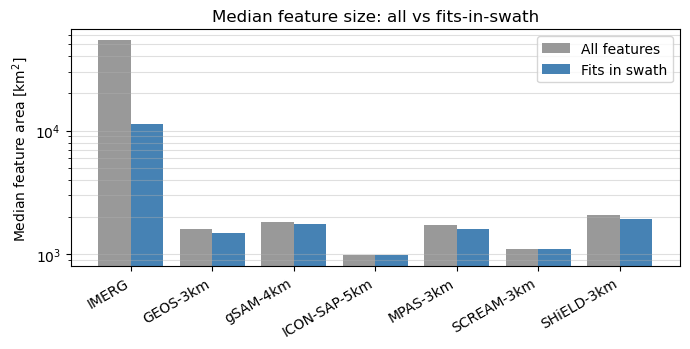

In [5]:
names = list(feature_data.keys())
med_all = [feature_data[n]["area_km2"].median() for n in names]
med_fits = [feature_data[n].filter(pl.col("fits_in_swath"))["area_km2"].median() for n in names]

x = np.arange(len(names))
w = 0.4
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(x - w / 2, med_all, w, label="All features", color="0.6")
ax.bar(x + w / 2, med_fits, w, label="Fits in swath", color="steelblue")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("Median feature area [km$^2$]")
ax.set_title("Median feature size: all vs fits-in-swath")
ax.legend()
ax.grid(alpha=0.4, axis="y", which="both")
fig.tight_layout()